수정할경우 파일 경로\
변수 명 정도

함수는 그대로 뜯어서 써도 됨\
함수 사용 예시는 df_original_2_1 사용 예시.

---
# 1.1 필요 라이브러리 및 폰트 로드

In [69]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)


print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


In [70]:
from scipy.stats import shapiro
from scipy import stats
from scipy.stats import levene


# 1.2 데이터 로드

In [71]:
# 1. 원본 데이터 로드
df_original_2 = pd.read_csv("for_통계_overall_data_product-2.csv")

# 3. 첫 번째 컬럼을 기준으로 분리된 데이터 프레임 생성
df_process_2 = pd.read_csv("for_통계_process_data_product-2.csv")
df_sensor_2 = pd.read_csv("for_통계_sensor_data_product-2.csv")
df_defects_2 = pd.read_csv("for_통계_defects_data_product-2.csv")

In [72]:
print(df_original_2.shape)
print(df_process_2.shape)
print(df_sensor_2.shape)
print(df_defects_2.shape)

(3328, 24)
(3328, 15)
(3328, 6)
(3328, 3)


In [73]:
# 3. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 행을 기준으로 1이 존재하면 불량으로 표현

defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 불량 데이터프레임
df_defects_2['is_defect'] = df_defects_2[defect_cols].max(axis=1)
# is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_defects_2_1 = df_defects_2.drop(columns=defect_cols)

# 전체 데이터프레임
df_original_2['is_defect'] = df_original_2[defect_cols].max(axis=1)
# is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_original_2_1 = df_original_2.drop(columns=defect_cols)


display(df_defects_2_1.head(5))
df_original_2_1.head(5)

,is_defect
0,0
1,0
2,0
3,0
4,0


,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.6,0.041,595,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,0
1,4208012_12,0.157,0.166,0.204,2.730,264,0.014,19,359,36.5,0.040,594,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.5,0.041,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
3,4210014_14,0.154,0.170,0.202,2.717,264,0.011,20,364,36.5,0.042,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
4,4211015_15,0.146,0.160,0.198,2.684,264,0.012,20,357,36.5,0.042,595,12.5,2.0,2.2,672.4,6.3,26.2,2.71,33.6,56.4,0


# 통계 계획 수립

## 타깃이 0/1 이진 변수
Welch t-test (정규성 어느 정도 + 등분산 불만족도 가능)\
    정규성, 등분산성 검증 필요

Mann-Whitney U test (비모수)

## 타깃이 3개 이상 범주형

0 = 양품 / 1 = 표면불량 / 2 = 구조불량 / 3 = 이물질불량

ANOVA\
Welch ANOVA\
Kruskal-Wallis\

# 1단계 간단한 기술통계
평균, 중앙값, 표준편차\
최소/최대\
왜도?

In [74]:
# 1. Process, Sensor 관련 데이터의 기술통계 딸깍
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 1-3. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
    display(stats_df)

In [75]:
# 2. 0/1 이진 변수 요약 딸깍
def create_binary_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 0/1 이진 변수 요약")
    print(f"{'='*80}\n")
    
    # 2-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 2-2. 요약표 생성
    summary_df = pd.DataFrame(index=df_copied.columns)
    summary_df['개수'] = df_copied.count()
    summary_df['0의 개수'] = (df_copied == 0).sum()
    summary_df['1의 개수'] = (df_copied == 1).sum()
    summary_df['1의 비율(%)'] = (df_copied.mean() * 100).round(2)
    summary_df['0의 비율(%)'] = ((1 - df_copied.mean()) * 100).round(2)
    
    display(summary_df)

In [76]:
create_statistics_summary(df_process_2, "process", exclude_cols="product_type" )
create_statistics_summary(df_sensor_2, "sensor")
create_binary_summary(df_defects_2_1, "defects",)


process의 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
velocity_1,3328.0,0.154473,0.004838,0.139,0.1515,0.156,0.158,0.162,-0.723734
velocity_2,3328.0,0.168620,0.004023,0.158,0.1660,0.168,0.172,0.178,0.066497
velocity_3,3328.0,0.202247,0.004953,0.184,0.2000,0.202,0.206,0.216,-0.215835
high_velocity,3328.0,2.553245,0.071882,2.470,2.5140,2.524,2.538,2.744,1.57937
cylinder_pressure,3328.0,264.764123,0.756067,247.000,265.0000,265.000,265.000,266.000,-15.937863
rapid_rise_time,3328.0,0.011660,0.000887,0.009,0.0110,0.012,0.012,0.014,-0.645471
biscuit_thickness,3328.0,17.589243,1.492139,2.000,17.0000,18.000,19.000,24.000,-1.538814
clamping_force,3328.0,370.342548,10.160827,346.000,361.0000,375.000,379.000,388.000,-0.470378
cycle_time,3328.0,35.704838,2.509634,33.600,35.8000,36.000,36.100,125.900,28.736696
pressure_rise_time,3328.0,0.036638,0.002946,0.031,0.0340,0.036,0.040,0.045,0.692732



sensor의 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,3328.0,655.703996,8.494439,635.30,648.70,655.4,662.50,678.10,0.273951
air_pressure,3328.0,6.120583,0.677288,4.60,5.60,6.2,6.80,7.10,-0.378966
coolant_temp,3328.0,26.923347,0.551408,25.90,26.50,26.8,27.30,28.10,0.282971
coolant_pressure,3328.0,2.689742,0.056365,2.58,2.63,2.7,2.74,2.79,-0.210328
factory_temp,3328.0,32.571725,1.522960,27.40,31.60,32.0,32.50,37.00,1.401438
factory_humidity,3328.0,63.190775,6.631947,45.50,61.80,64.3,69.10,72.30,-1.083763



defects 0/1 이진 변수 요약



,개수,0의 개수,1의 개수,1의 비율(%),0의 비율(%)
is_defect,3328,2382,946,28.43,71.57


### 0. 공통 해석
process, sensor, defects 데이터는 총 3,328개의 관측치로 구성되어 있다.

### 1. process 데이터 기술통계 해석
velocity_1, velocity_2, velocity_3, cycle_time, pressure_rise_time 등은 표준편차가 크지 않아 전반적으로 공정 조건이 일정하게 유지

high_velocity, spray_time, spray_2_time은 왜도가 상대적으로 크게 나타나 일부 값이 한쪽으로 치우친 비대칭 분포

cylinder_pressure와 spray_1_time의 값이 왜 0으로 나오지? 클램핑으로 값을 묶어서 저렇게 됨

### 2. sensor 데이터 기술통계 해석
melting_furnace_temp, coolant_temp, coolant_pressure는 평균 주변에 비교적 고르게 분포하며 큰 변동은 보이지 않음

반면 factory_temp는 양의 왜도, factory_humidity는 음의 왜도가 비교적 크게 나타나 환경 변수 일부는 비대칭 분포

### 3. defects 데이터 기술통계 해석


## 1-1 단계. 상관계수

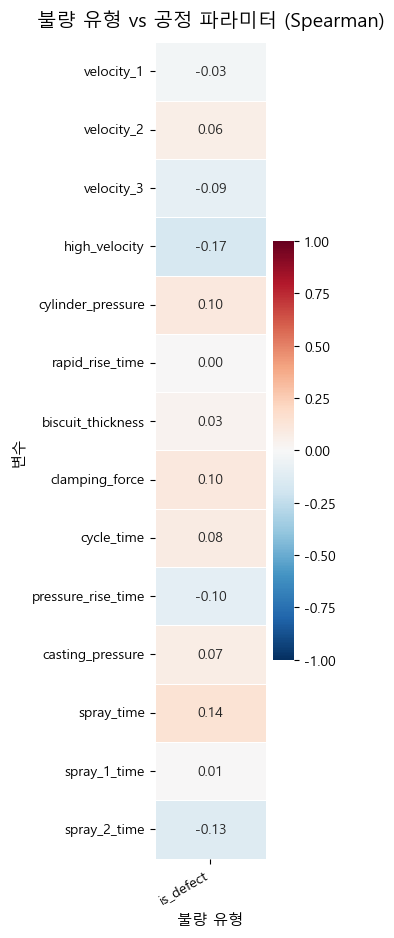

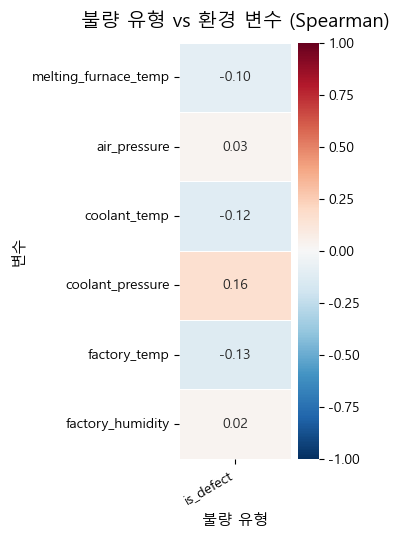

In [77]:
DEFECT_COLS = [
    "is_defect"
]

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 출력
plot_corr_heatmap(df_original_2, DEFECT_COLS, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_2, DEFECT_COLS, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')

# 2단계. 정규성 검정

## Shapiro-Wilk

In [78]:
# 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):
    """Shapiro-Wilk 정규성 검정"""
    print(f"\n{'='*80}")
    print(f"{df_name} 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")
    
    #  exclude_cols에 속한 컬럼 제외
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()
    
        # 정규성 확인: Shapiro-Wilk
        stat, p_value = shapiro(series)
    
        # H0: 정규성을 만족한다.
        # H1: 정규성을 불만족한다.
        if p_value > alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        # 출력값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result])
    
    # 출력화면
    shapiro_df = pd.DataFrame(
        result_list, 
        columns=[
            "변수명", 
            "Shapiro 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(shapiro_df)
    
    return shapiro_df

In [79]:
shapiro_df_original_2 = create_shapiro_summary(
    df_original_2_1,
    "공정/센서",
    exclude_cols=['shot_key', 'is_defect',]
)


공정/센서 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
velocity_1,0.926543,1.316477e-37,정규성 불만족
velocity_2,0.969190,3.757826e-26,정규성 불만족
velocity_3,0.984859,2.096279e-18,정규성 불만족
high_velocity,0.648671,9.326014e-64,정규성 불만족
cylinder_pressure,0.253951,7.152509e-79,정규성 불만족
rapid_rise_time,0.760192,1.013079e-56,정규성 불만족
biscuit_thickness,0.889750,1.039510e-43,정규성 불만족
clamping_force,0.891286,1.720679e-43,정규성 불만족
cycle_time,0.153969,1.478039e-81,정규성 불만족


## Q-Q Plot

In [ ]:
# 테이블(데이터프레임)의 컬럼들로 QQ plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    """QQPlot 테이블"""
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        # Q-Q plot
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

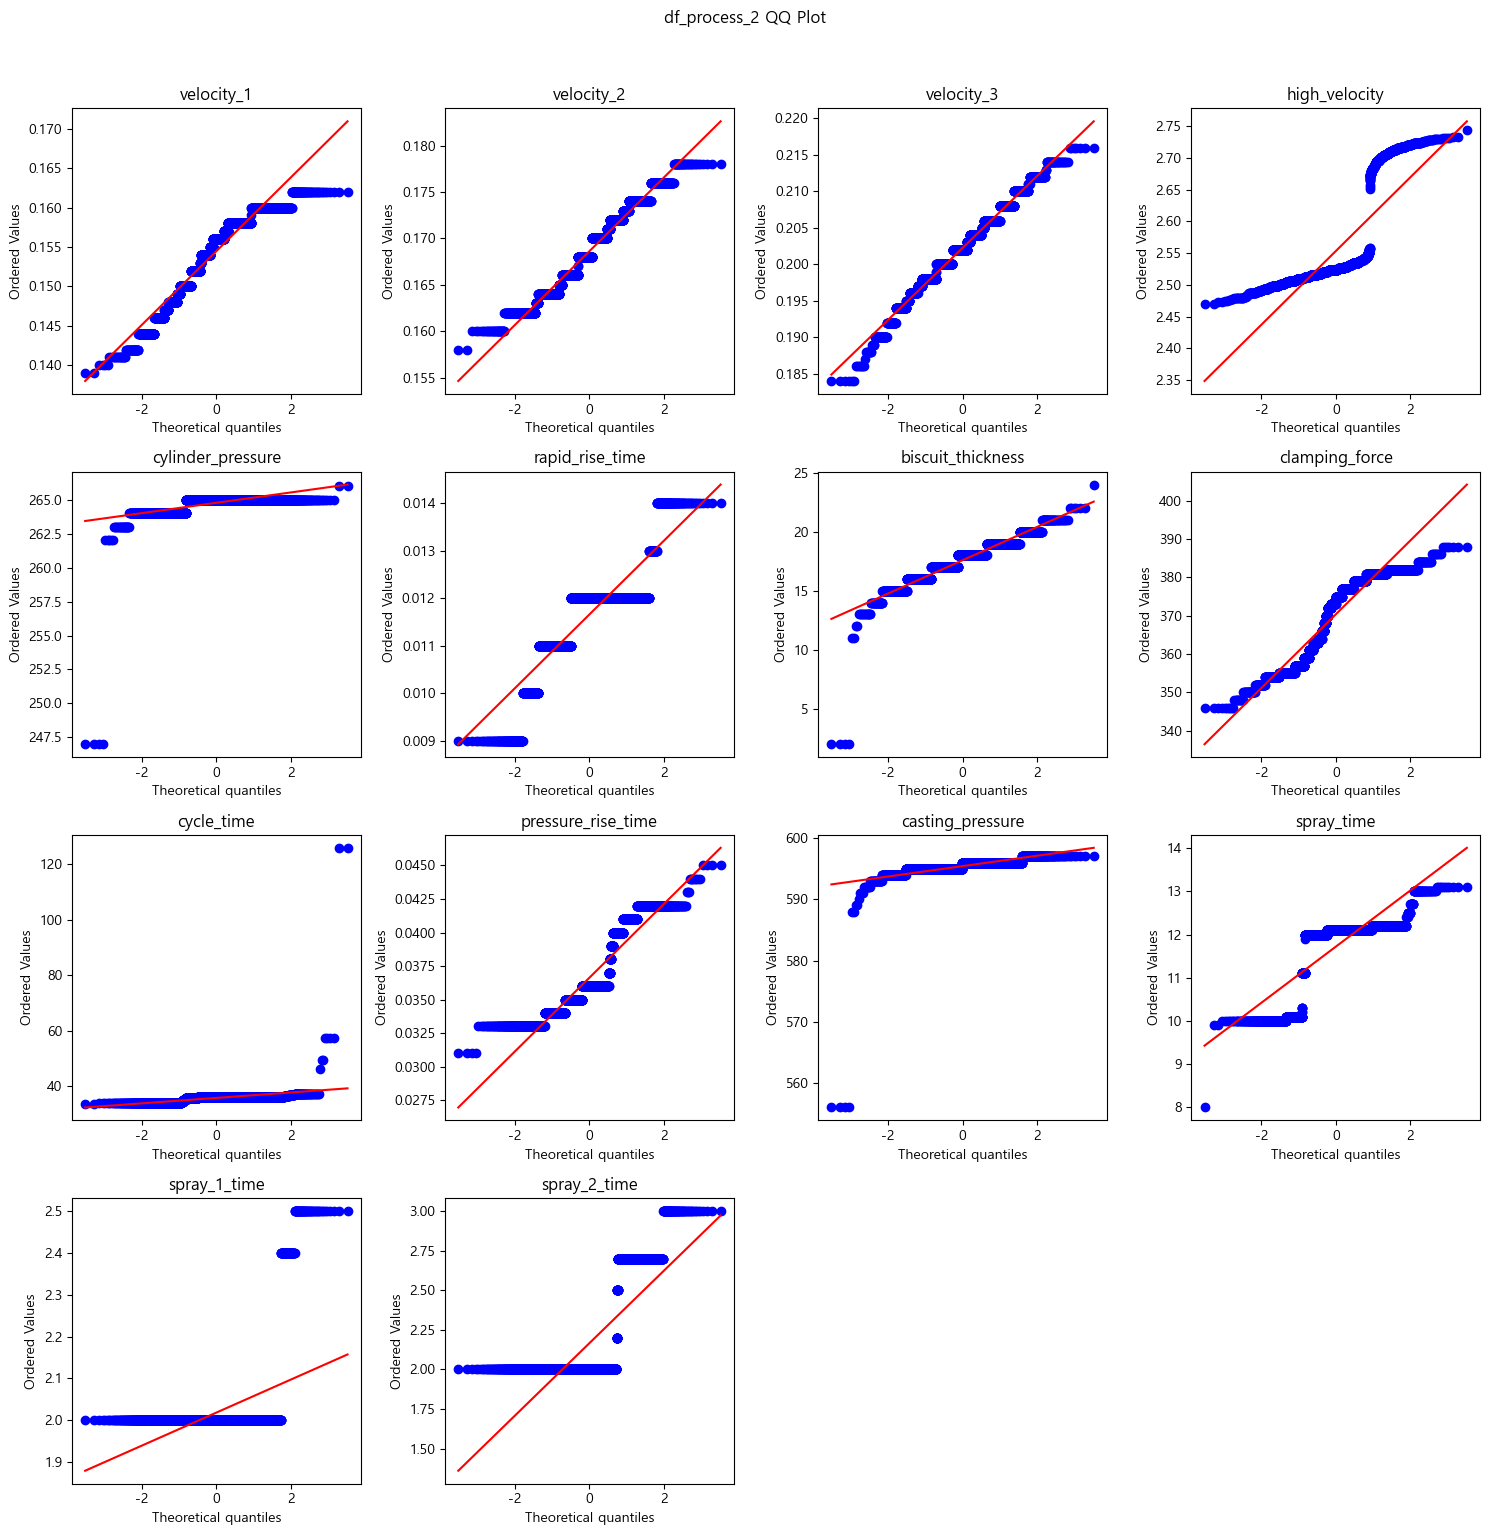

In [81]:
plot_qq_table(df_process_2, 
                title="df_process_2 QQ Plot",
    )

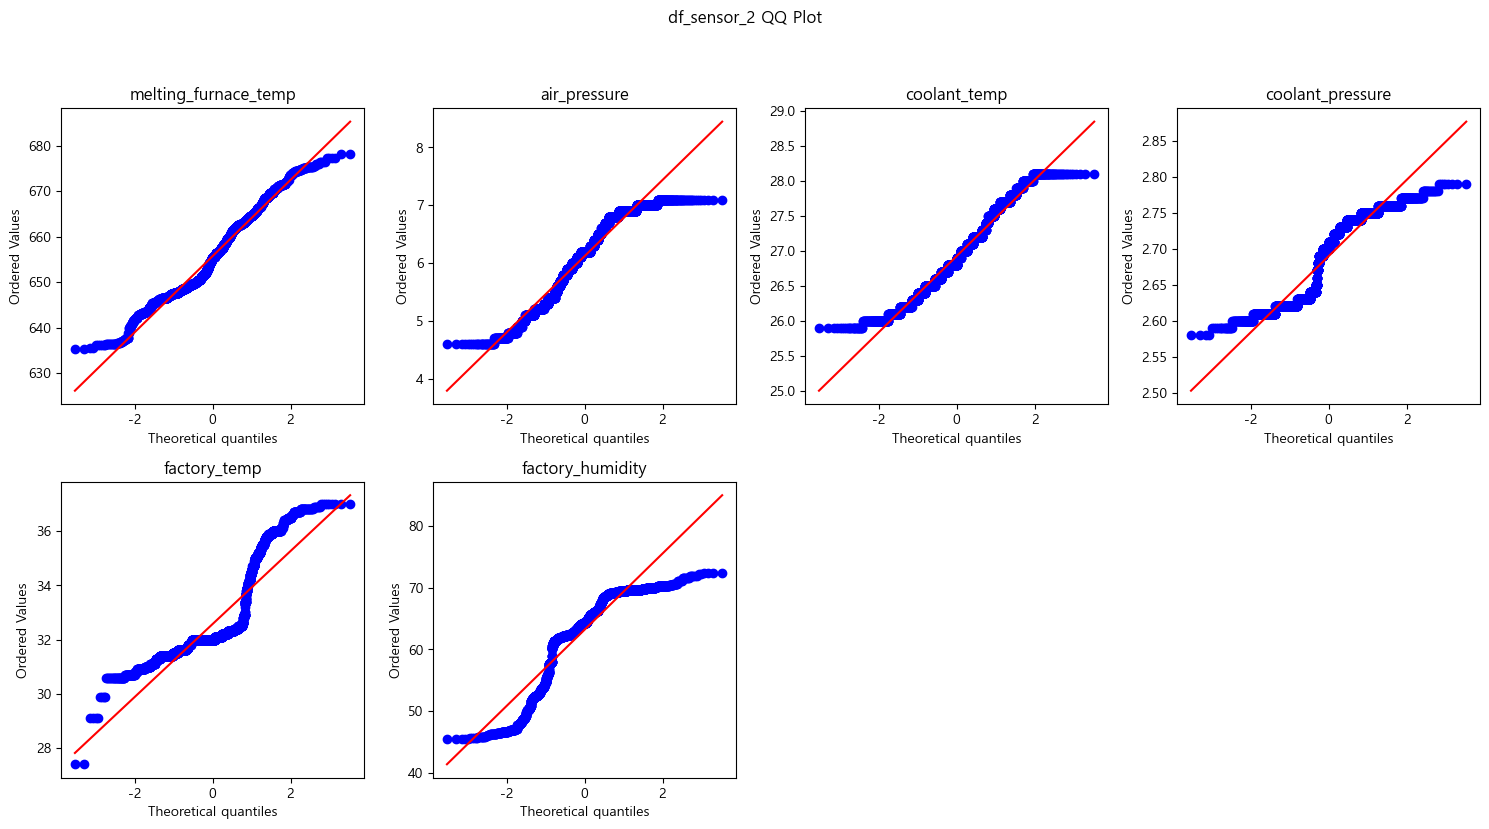

In [82]:
plot_qq_table(df_sensor_2, 
                title="df_sensor_2 QQ Plot", )

# 3단계. 등분산성 검정

In [83]:
from scipy.stats import levene

# 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """등분산성 검정 (Levene test)"""
    print(f"\n{'='*80}")
    print(f"{df_name} 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

        
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')    
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col]

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
    
        # 등분산성 검정: levene
        stat, p_value = levene(group_0, group_1)

        # H0: 두 그룹의 분산이 같다 (등분산)
        # H1: 두 그룹의 분산이 다르다 (이분산)
        if p_value > alpha:
            result = "등분산 가정 가능"
        else:
            result = "등분산 가정 불가"

        # 출력 값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result
        ]
    )
    
    # 출력화면
    levene_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
            "Levene 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [84]:
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2_1,
    "is_defect",
    "df_process_2",
    exclude_cols=['shot_key']
)

process_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2_1,
    "is_defect",
    "df_sensor_2",
)


df_process_2 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,4.480292,3.436193e-02,등분산 가정 불가
velocity_2,0.730217,3.928743e-01,등분산 가정 가능
velocity_3,1.830792,1.761259e-01,등분산 가정 가능
high_velocity,188.751329,8.084364e-42,등분산 가정 불가
cylinder_pressure,5.546086,1.857985e-02,등분산 가정 불가
rapid_rise_time,0.714535,3.980031e-01,등분산 가정 가능
biscuit_thickness,0.580366,4.462228e-01,등분산 가정 가능
clamping_force,163.045258,1.734345e-36,등분산 가정 불가
cycle_time,15.444339,8.669984e-05,등분산 가정 불가



df_sensor_2 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,19.173745,1.230211e-05,등분산 가정 불가
air_pressure,24.267707,8.792250e-07,등분산 가정 불가
coolant_temp,3.906079,4.819422e-02,등분산 가정 불가
coolant_pressure,7.258745,7.091103e-03,등분산 가정 불가
factory_temp,108.956851,4.036253e-25,등분산 가정 불가
factory_humidity,176.767310,2.442028e-39,등분산 가정 불가


# 4단계. 실제 집단 차이 검정


A. 타깃이 0/1 이진 변수
- 정규성 어느 정도 괜찮고 평균 비교 목적이면 → Welch t-test → Cohen's d
- 분포가 많이 찌그러졌거나 이상치 영향이 크면 → Mann-Whitney U → rank-
- 효과 크기

B. 타깃이 3개 이상 다중 범주
- 정규성/등분산성 괜찮으면 → ANOVA → Tukey → 효과크기: eta squared(η²) or omega squared(ω²)
- 등분산성 안 맞으면 → Welch ANOVA → Games-Howell → 효과크기: eta squared(η²) or omega squared(ω²)
- 비모수로 가면 → Kruskal-Wallis → Dunn test (보정 포함) → 효과크기: epsilon squared(ε²)

## A. 타깃이 0/1 이진 변수

### welch-t 검정

In [85]:
def cohens_d_ind(group1, group2): # 독립표본 d(합동표준편차 사용)
    """Cohen's d — 독립표본: d = |x̄₁ - x̄₂| / s_pooled"""
    n1, n2 = len(group1), len(group2)
    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) # 합동 분산 
    return (np.mean(group1) - np.mean(group2)) / s_pooled

In [86]:
from scipy.stats import ttest_ind

# Welch t-test 검정 + Cohen's d 효과크기
def create_welch_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """Welch t-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Welch t-test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()
    
        # 통계검정: Welch t-검정 (등분산 가정 X)
        # 양측검정 (two-sided)
        t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False, alternative='two-sided')
        
        # 효과크기: Cohen's d
        cohen_d = cohens_d_ind(group_0, group_1)
    
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 평균이 같다. (μ0 = μ1)
        # 대립가설(H1): 두 집단의 평균이 다르다. (μ0 ≠ μ1)
        if p_value >= alpha:
            result = "유의한 차이 없음 ㅠㅠ"
        else:
            result = "유의한 차이 있음!!!!!"

        # 효과크기 판정 = 기준은 유동적
        if abs(cohen_d) < 0.1:
            effect = "매우 작은 효과"
        elif abs(cohen_d) < 0.3:
            effect= "작은 효과"
        elif abs(cohen_d) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력값 조정
        result_list.append([
            col,
            len(group_0),
            len(group_1),
            t_stat,
            p_value,
            cohen_d,
            result,
            effect
        ])


    # 출력화면 조정
    welch_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명",
            "해당 불량이 없는 샷",
            "해당 불량이 있는 샷",
            "t 통계량", 
            "p-value", 
            "Cohen's d", 
            "판정",
            "효과크기 판정"
        ]
    ).set_index("변수명")
    # 절댓값 기준 효과크기 절대값 내림차순으로 나열
    welch_df = welch_df.sort_values("Cohen's d", key=abs, ascending=False)
    display(welch_df)
    
    return welch_df

In [87]:
welch_surface = create_welch_summary(
    df_original_2_1,
    df_defects_2_1,
    "is_defect",
    "df_original_2_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_original_2_1 실제 집단 차이 검정 (Welch t-test) - 기준: is_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,t 통계량,p-value,Cohen's d,판정,효과크기 판정
변수명,,,,,,,
high_velocity,2382,946,17.553665,6.444589e-66,0.515336,유의한 차이 있음!!!!!,큰 효과
factory_temp,2382,946,13.715566,2.104785e-41,0.441795,유의한 차이 있음!!!!!,중간 효과
coolant_pressure,2382,946,-8.175501,5.711403e-16,-0.317986,유의한 차이 있음!!!!!,중간 효과
clamping_force,2382,946,-8.933557,8.894569e-19,-0.317252,유의한 차이 있음!!!!!,중간 효과
coolant_temp,2382,946,6.806628,1.367599e-11,0.260440,유의한 차이 있음!!!!!,작은 효과
factory_humidity,2382,946,-8.148410,5.567848e-16,-0.259178,유의한 차이 있음!!!!!,작은 효과
spray_2_time,2382,946,7.137874,1.327725e-12,0.259159,유의한 차이 있음!!!!!,작은 효과
spray_time,2382,946,-7.622387,3.593887e-14,-0.257419,유의한 차이 있음!!!!!,작은 효과
velocity_3,2382,946,5.483617,4.760016e-08,0.207639,유의한 차이 있음!!!!!,작은 효과


### Mann-Whitney U 검정

In [88]:
from scipy.stats import mannwhitneyu
import pingouin as pg

# Mann-Whitney U 검정 + rank-biserial 효과크기
def create_mannwhitney_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """mannwhitney u-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Mann-Whitney U) - 기준: {target_col}")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()

        # Mann–Whitney U
        # 입력 순서가 중요 group_1을 먼저 넣으면, RBC 부호 해석이 직관적이 됨
        #  RBC > 0  → 불량(1) 그룹 값이 더 큰 경향
        #  RBC < 0  → 불량(1) 그룹 값이 더 작은 경향

        # Pingouin(pg.mwu)은 U 통계량, p-value, 효과크기(RBC)를 한 번에 반환함
        out = pg.mwu(group_1, group_0, alternative='two-sided')
        u_stat  = out["U_val"].values[0] # u_stat
        p_value = out["p_val"].values[0] # p_value
        # 효과크기: rank-biserial correlation
        rbc = out["RBC"].values[0] # rbc 
        
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 분포가 같다. (순위가 비슷하다)  → 차이가 없다
        # 대립가설(H1): 두 집단의 분포가 다르다. (순위가 다르다) → 차이가 있다
        if p_value >= alpha:
            result = "유의한 차이 없음 ㅠㅠ"
        else:
            result = "유의한 차이 있음!!!!!"

        # 효과크기 판정 = 기준은 유동적
        if abs(rbc) < 0.1:
            effect = "매우 작은 효과"
        elif abs(rbc) < 0.3:
            effect= "작은 효과"
        elif abs(rbc) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력값
        result_list.append([
            col, 
            len(group_0),
            len(group_1),
            u_stat, 
            p_value, 
            rbc, 
            result, 
            effect
        ])
    
    # 출력화면
    mannwhitney_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
                "해당 불량이 없는 샷",
                "해당 불량이 있는 샷",
                "U 통계량", 
                "p-value", 
                "rank-biserial", 
                "판정",
                "효과크기 판정"
            ]
    ).set_index("변수명")
    # 절댓값 기준 효과크기 절대값 내림차순으로 나열
    mannwhitney_df = mannwhitney_df.sort_values('rank-biserial', key=abs, ascending=False)
    display(mannwhitney_df)
    
    return mannwhitney_df


In [89]:
mannwhitney_surface = create_mannwhitney_summary(
    df_original_2_1,
    df_defects_2_1,
    "is_defect",
    "df_original_2_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_original_2_1 실제 집단 차이 검정 (Mann-Whitney U) - 기준: is_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,U 통계량,p-value,rank-biserial,판정,효과크기 판정
변수명,,,,,,,
high_velocity,2382,946,882524.0,1.543591e-22,-0.216708,유의한 차이 있음!!!!!,작은 효과
coolant_pressure,2382,946,1352485.0,1.243316e-19,0.200410,유의한 차이 있음!!!!!,작은 효과
spray_time,2382,946,1321119.0,3.613817e-16,0.172571,유의한 차이 있음!!!!!,작은 효과
factory_temp,2382,946,946196.0,3.719025e-13,-0.160195,유의한 차이 있음!!!!!,작은 효과
coolant_temp,2382,946,957375.0,1.172337e-11,-0.150273,유의한 차이 있음!!!!!,작은 효과
clamping_force,2382,946,1273253.5,4.069019e-09,0.130087,유의한 차이 있음!!!!!,작은 효과
melting_furnace_temp,2382,946,982148.0,7.423824e-09,-0.128286,유의한 차이 있음!!!!!,작은 효과
pressure_rise_time,2382,946,989396.5,2.404079e-08,-0.121852,유의한 차이 있음!!!!!,작은 효과
spray_2_time,2382,946,990073.0,1.135534e-13,-0.121252,유의한 차이 있음!!!!!,작은 효과
